<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/19_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TEXT CLASSIFICATION AND SENTIMENT ANALYSIS**

##**Improving Customer Satisfaction through Automated Review Sentiment Analysis**

**Data Preparation**

In [ ]:

import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

df = pd.read_csv("amazonreviews.tsv", sep="\t")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)

Shape: (10000, 2)

Columns: ['label', 'review']

First 5 rows:


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."



Data types:
label     object
review    object
dtype: object


**Data Cleaning**

In [ ]:

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.dropna(subset=["review", "label"])

df["review"] = df["review"].astype(str).str.lower().str.strip()
df["label"] = df["label"].astype(str).str.lower().str.strip()

print("\nShape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values:
label     0
review    0
dtype: int64

Duplicate rows: 0

Shape after cleaning: (10000, 2)

Missing values after cleaning:
label     0
review    0
dtype: int64


**Text Preprocessing**

In [ ]:

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(preprocess_text)

print(df[["review", "clean_review"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                              review  \
0  stuning even for the non-gamer: this sound tra...   
1  the best soundtrack ever to anything.: i'm rea...   
2  amazing!: this soundtrack is my favorite music...   
3  excellent soundtrack: i truly like this soundt...   
4  remember, pull your jaw off the floor after he...   

                                        clean_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hand in...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


**Sentiment Distribution**

label
neg    5097
pos    4903
Name: count, dtype: int64


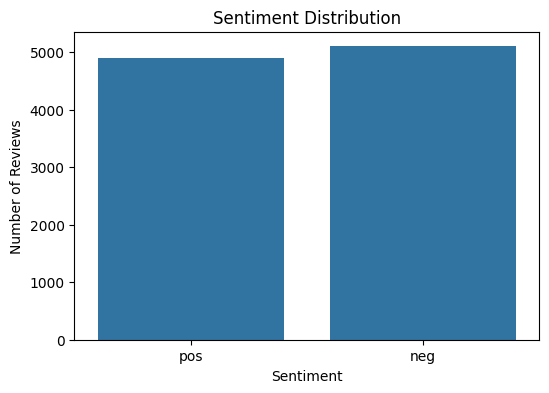

In [ ]:

print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

**Word Clouds**

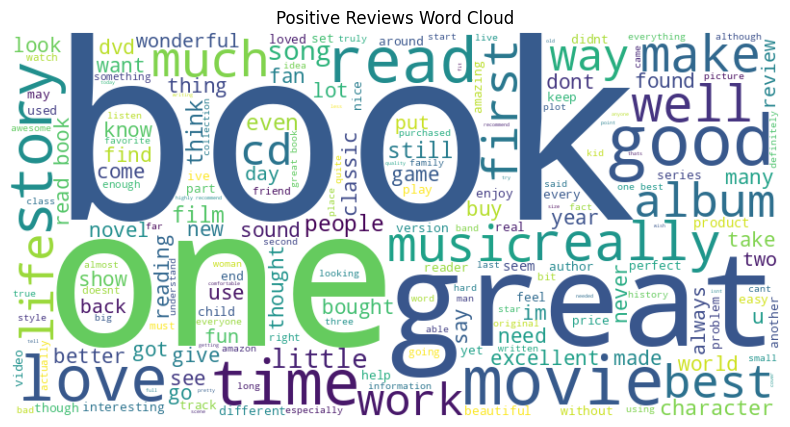

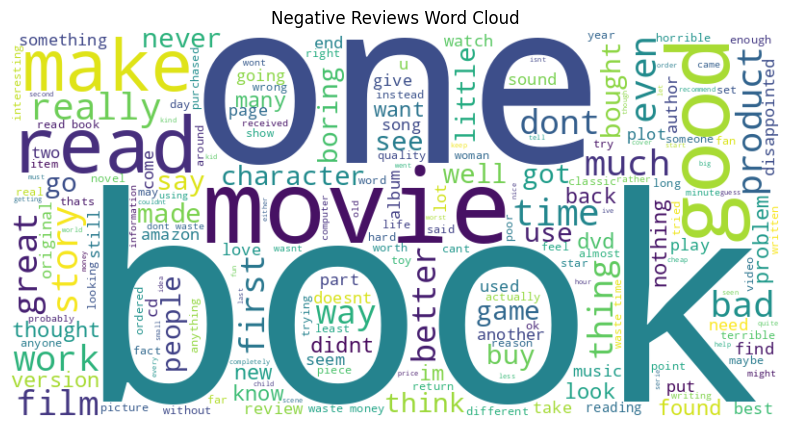

In [ ]:

from wordcloud import WordCloud

positive_text = " ".join(df.loc[df["label"] == "pos", "clean_review"])
negative_text = " ".join(df.loc[df["label"] == "neg", "clean_review"])

positive_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

**Most Common Words**

In [ ]:

from collections import Counter

positive_words = Counter(positive_text.split())
negative_words = Counter(negative_text.split())

print("Most common positive words:")
print(positive_words.most_common(20))

print("\nMost common negative words:")
print(negative_words.most_common(20))

Most common positive words:
[('book', 3861), ('great', 2089), ('one', 1936), ('good', 1637), ('read', 1574), ('like', 1320), ('movie', 1295), ('time', 1136), ('love', 1038), ('would', 943), ('get', 936), ('well', 857), ('story', 857), ('really', 828), ('best', 801), ('first', 708), ('make', 705), ('work', 679), ('year', 677), ('much', 650)]

Most common negative words:
[('book', 3683), ('one', 2119), ('movie', 1732), ('like', 1570), ('would', 1438), ('get', 1285), ('time', 1275), ('dont', 1240), ('read', 1238), ('good', 1137), ('even', 898), ('buy', 821), ('really', 778), ('much', 769), ('make', 761), ('work', 761), ('story', 756), ('bad', 749), ('money', 747), ('first', 736)]


**TF-IDF Feature Extraction**

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df["clean_review"])
y = df["label"].map({"neg": 0, "pos": 1})

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (10000, 10000)


**Train Test Split**

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


**Logistic Regression Model**

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Accuracy: 0.8535
Precision: 0.8517382413087935
Recall: 0.8491335372069317
F1-score: 0.8504338948443083

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      1019
    Positive       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



**SVM Model**

In [ ]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1-score:", f1_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=["Negative", "Positive"]))

Accuracy: 0.8425
Precision: 0.8377281947261663
Recall: 0.8419979612640163
F1-score: 0.8398576512455516

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.85      1019
    Positive       0.84      0.84      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



**Model Comparison**

In [ ]:

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, svm_pred)
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8535,0.851738,0.849134,0.850434
1,Linear SVM,0.8425,0.837728,0.841998,0.839858


**Cross Validation**

In [ ]:

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logistic_cv = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=cv,
    scoring="f1"
)

svm_cv = cross_val_score(
    LinearSVC(),
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression CV F1 scores:", logistic_cv)
print("Logistic Regression Mean F1:", logistic_cv.mean())

print("\nLinear SVM CV F1 scores:", svm_cv)
print("Linear SVM Mean F1:", svm_cv.mean())

Logistic Regression CV F1 scores: [0.85699797 0.86039297 0.85832472 0.85771343 0.85435897]
Logistic Regression Mean F1: 0.8575576118748038

Linear SVM CV F1 scores: [0.85110664 0.85817432 0.85714286 0.85442721 0.84599797]
Linear SVM Mean F1: 0.8533698001808627


**Confusion Matrix**

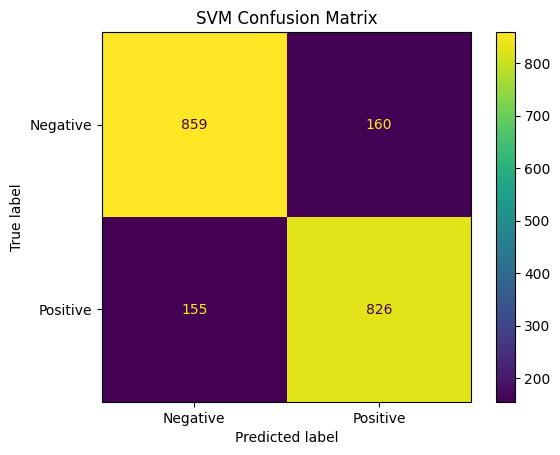

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

**Important Sentiment Features**

In [ ]:

feature_names = vectorizer.get_feature_names_out()
coefficients = svm_model.coef_[0]

positive_indices = np.argsort(coefficients)[-20:][::-1]
negative_indices = np.argsort(coefficients)[:20]

print("Top positive features:")
for index in positive_indices:
    print(feature_names[index], coefficients[index])

print("\nTop negative features:")
for index in negative_indices:
    print(feature_names[index], coefficients[index])

Top positive features:
great 3.492410291554603
excellent 3.171590976974459
perfect 2.850721234301275
love 2.7022546876418714
wonderful 2.072915557394348
best 2.0725191039542876
pleased 2.068989568314474
awesome 2.054607610170956
amazing 2.045387076392227
favorite 1.9658241803824648
perfectly 1.932785935153933
must 1.8827208662254507
solid 1.780045620181857
beautiful 1.7393362590184227
good 1.703307525381899
awsome 1.6367274260968503
well 1.6070989660310513
censorship 1.53137587925674
intense 1.5215664810272922
highly recommend 1.4947570897918785

Top negative features:
boring -3.5310643105556454
disappointed -3.0994819697427265
poor -3.0108738851124426
worst -2.8571252736073007
disappointing -2.699406672358481
bad -2.6192846246505743
waste -2.583403881011011
horrible -2.2781736290161176
terrible -2.0904057182858233
disappointment -2.0158345653647065
stopped -1.8097535124320696
useless -1.7418135259825949
misleading -1.7325408085372176
want read -1.7038632271255252
nothing -1.6612341742

**Sentiment Prediction**

In [ ]:

new_reviews = [
    "This product is excellent and I absolutely love it.",
    "The product is terrible and I completely hate it.",
    "Amazing quality and very good experience."
]

new_reviews_clean = [preprocess_text(review) for review in new_reviews]
new_reviews_tfidf = vectorizer.transform(new_reviews_clean)

predictions = svm_model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: This product is excellent and I absolutely love it.
Predicted Sentiment: Positive

Review: The product is terrible and I completely hate it.
Predicted Sentiment: Negative

Review: Amazing quality and very good experience.
Predicted Sentiment: Positive



##**Final Analysis**
* The sentiment analysis system classifies Amazon customer reviews into positive and negative categories.

* TF-IDF was used to convert review text into numerical features. Logistic Regression and Linear SVM were used as classification models. Accuracy, precision, recall and F1-score were used for evaluation, while 5-fold stratified cross-validation was used to assess model robustness.

* The word clouds and frequent-word analysis help identify commonly occurring words in positive and negative reviews. The trained model can also predict the sentiment of new customer reviews.

* This system can help an e-commerce company monitor customer feedback, identify negative sentiment and respond to customer complaints more quickly.